# PatchCore EfficientNet-B1 One-Layer — Combined Best Approach

This notebook merges the best practices from both prototype notebooks:

| Design choice | Source | Rationale |
|---|---|---|
| `wafer_to_tensor`: int → one-hot → resize | NB2 | No float round-trip / rounding artifacts |
| `patch_embed_dim = 128` | NB2 | Wafer maps are low-info (3 binary channels); 512 over-parameterises |
| 500 test defects | NB2 | Better defect-type coverage, more stable AUC |
| GPU-resident memory bank | NB2 | No double-normalisation bug, no PCIe round-trips |
| z-score score normalisation | NB2 | Stable thresholds across runs and datasets |
| Seeded CPU `torch.Generator` for sampling | NB1 | Fully reproducible memory bank across runs |
| Val-normal-only threshold (no defect leakage) | NB1 | Honest evaluation — threshold never sees defect scores |
| Secondary 70k/3.5k holdout re-evaluation | NB1 | Stress-tests the fitted checkpoint on a larger distribution |
| UMAP diagnostic export | NB1 | Visual sanity check on embedding quality |
| CSV / JSON / checkpoint artifact saves | NB1 | Reproducible benchmarking |

**Pipeline summary (one run):**
1. Load `LSWMD.pkl` and clean labels
2. Build split: 40k train-normal / 5k tune-normal / 500 tune-defect / 10k test-normal / 500 test-defect
3. Convert wafer maps: `int → one-hot (3ch) → resize 224×224` (NB2 clean path)
4. Build GPU-resident memory bank with seeded sampling (hybrid)
5. Score all splits; z-score normalise against train-normal distribution
6. Threshold = 95th percentile of **tune-normal** z-scores (no defect leakage)
7. Evaluate on held-out test split; secondary 70k holdout re-eval
8. Export UMAP, CSVs, JSON summary, checkpoint

**Artifacts saved to:** `artifacts/x224/patchcore_efficientnet_b1_combined/`

In [1]:
from __future__ import annotations

import copy
import gc
import json
import os
import pickle
import random
import sys
import time
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import EfficientNet_B1_Weights, efficientnet_b1
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── GPU flags ────────────────────────────────────────────────────────────────
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}')

C:\Users\kyler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Edit these values to change the experiment.

CONFIG: dict[str, Any] = {
    'run': {
        'variant_name': 'patchcore_efficientnet_b1_combined',
        'raw_pickle': 'data/raw/LSWMD.pkl',
        'output_dir': 'artifacts/x224/patchcore_efficientnet_b1_combined',
        'seed': 42,
    },
    'split': {
        'image_size': 224,          # input resolution fed to EfficientNet
        'train_normal_count': 20_000,
        'tune_normal_count': 5_000,
        'tune_defect_count': 500,   # used only for per-class breakdown, NOT threshold
        'test_normal_count': 10_000,
        'test_defect_count': 500,   # NB2: larger pool for stable AUC
    },
    'model': {
        'batch_size': 128,
        'memory_bank_max_patches': 200_000,
        'score_chunk': 1024,
        'patchcore_nn_k': 3,
        'topk_patch_ratio': 0.03,
        'effnet_feature_idx': 3,    # EfficientNet-B1 block index (one-layer)
        'patch_embed_dim': 128,     # NB2: low-info wafer maps don't need 512
        'amp': True,
    },
    'scoring': {
        'threshold_quantile': 0.95, # NB1: val-NORMAL only, no defect leakage
    },
    'holdout': {
        'test_normal_count': 70_000,
        'test_defect_count': 3_500,
    },
}

SEED          = CONFIG['run']['seed']
IMAGE_SIZE    = CONFIG['split']['image_size']
BATCH_SIZE    = CONFIG['model']['batch_size']
OUTPUT_DIR    = Path(CONFIG['run']['output_dir'])
VARIANT_NAME  = CONFIG['run']['variant_name']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f'Output dir : {OUTPUT_DIR}')
print(f'Variant    : {VARIANT_NAME}')
print(json.dumps({k: v for k, v in CONFIG['model'].items()}, indent=2))

Output dir : artifacts\x224\patchcore_efficientnet_b1_combined
Variant    : patchcore_efficientnet_b1_combined
{
  "batch_size": 128,
  "memory_bank_max_patches": 200000,
  "score_chunk": 1024,
  "patchcore_nn_k": 3,
  "topk_patch_ratio": 0.03,
  "effnet_feature_idx": 3,
  "patch_embed_dim": 128,
  "amp": true
}


In [3]:
# ── Data loading & splitting ───────────────────────────────────────────────────
# NB1: robust legacy-pickle reader
# NB2: clean label parsing (no float round-trip)

import pandas.core.indexes as _core_indexes
sys.modules['pandas.indexes'] = _core_indexes

def _read_legacy_pickle(path: str | Path) -> pd.DataFrame:
    with Path(path).open('rb') as fh:
        return pickle.load(fh, encoding='latin1')

def _find_pickle(path_str: str) -> Path:
    """Resolve raw pickle path relative to cwd or repo root."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        if (root / '.git').exists() or (root / 'artifacts').exists():
            candidate = root / path_str
            if candidate.exists():
                return candidate
    candidate = Path(path_str)
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f'Cannot find {path_str}')

def _parse_label(value: Any) -> str:
    """NB2 clean integer-array label parser."""
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        return 'unknown' if len(arr) == 0 else str(arr[0])
    return str(value).strip()

# Load
raw_path = _find_pickle(CONFIG['run']['raw_pickle'])
df = _read_legacy_pickle(raw_path).copy()
print(f'Raw shape: {df.shape}')

df['failure_label'] = df['failureType'].apply(_parse_label).str.strip()
_invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(_invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()
print(f'Normal wafers: {len(normal_df):,} | Defect wafers: {len(defect_df):,}')

# Split
cfg_s = CONFIG['split']
need_n = cfg_s['train_normal_count'] + cfg_s['tune_normal_count'] + cfg_s['test_normal_count']
need_d = cfg_s['tune_defect_count'] + cfg_s['test_defect_count']
assert len(normal_df) >= need_n, f'Need {need_n} normals, found {len(normal_df)}'
assert len(defect_df) >= need_d, f'Need {need_d} defects, found {len(defect_df)}'

rng = np.random.default_rng(SEED)
ndf = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ddf = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

n0, n1, n2, n3 = (
    0,
    cfg_s['train_normal_count'],
    cfg_s['train_normal_count'] + cfg_s['tune_normal_count'],
    cfg_s['train_normal_count'] + cfg_s['tune_normal_count'] + cfg_s['test_normal_count'],
)
train_df        = ndf.iloc[n0:n1].copy()
tune_normal_df  = ndf.iloc[n1:n2].copy()
test_normal_df  = ndf.iloc[n2:n3].copy()
tune_defect_df  = ddf.iloc[:cfg_s['tune_defect_count']].copy()
test_defect_df  = ddf.iloc[cfg_s['tune_defect_count']:cfg_s['tune_defect_count'] + cfg_s['test_defect_count']].copy()

print('\nSplit summary:')
print(pd.DataFrame([
    {'split': 'train_normal',  'count': len(train_df),       'anomalies': 0},
    {'split': 'tune_normal',   'count': len(tune_normal_df), 'anomalies': 0},
    {'split': 'tune_defect',   'count': len(tune_defect_df), 'anomalies': len(tune_defect_df)},
    {'split': 'test_normal',   'count': len(test_normal_df), 'anomalies': 0},
    {'split': 'test_defect',   'count': len(test_defect_df), 'anomalies': len(test_defect_df)},
]).to_string(index=False))

Raw shape: (811457, 6)
Normal wafers: 147,431 | Defect wafers: 25,519

Split summary:
       split  count  anomalies
train_normal  20000          0
 tune_normal   5000          0
 tune_defect    500        500
 test_normal  10000          0
 test_defect    500        500


In [4]:
# ── Wafer map → tensor  (NB2 clean path: int → one-hot → resize) ──────────────
# No float ÷2 round-trip. Values are already discrete {0,1,2}; clip + one-hot
# then interpolate is lossless for nearest-mode resize.

def wafer_to_tensor(wafer_map: Any, size: int = 224) -> torch.Tensor:
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # (3, H, W)
    if x.shape[-1] != size or x.shape[-2] != size:
        x = F.interpolate(x.unsqueeze(0), size=(size, size), mode='nearest').squeeze(0)
    return x

def build_tensors(frame: pd.DataFrame, size: int = 224) -> tuple[torch.Tensor, torch.Tensor]:
    imgs = [wafer_to_tensor(w, size=size) for w in tqdm(frame['waferMap'].values, desc='encode', leave=False)]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

set_seed(SEED)
print('Encoding tensors...')
X_train,        y_train        = build_tensors(train_df,       IMAGE_SIZE)
X_tune_normal,  y_tune_normal  = build_tensors(tune_normal_df, IMAGE_SIZE)
X_tune_defect,  y_tune_defect  = build_tensors(tune_defect_df, IMAGE_SIZE)
X_test_normal,  y_test_normal  = build_tensors(test_normal_df, IMAGE_SIZE)
X_test_defect,  y_test_defect  = build_tensors(test_defect_df, IMAGE_SIZE)

loader_kw = dict(batch_size=BATCH_SIZE, shuffle=False)
train_loader        = DataLoader(TensorDataset(X_train,       y_train),       **loader_kw)
tune_normal_loader  = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kw)
tune_defect_loader  = DataLoader(TensorDataset(X_tune_defect, y_tune_defect), **loader_kw)
test_normal_loader  = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kw)
test_defect_loader  = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kw)

print(f'X_train:       {tuple(X_train.shape)}')
print(f'X_tune_normal: {tuple(X_tune_normal.shape)}')
print(f'X_tune_defect: {tuple(X_tune_defect.shape)}')
print(f'X_test_normal: {tuple(X_test_normal.shape)}')
print(f'X_test_defect: {tuple(X_test_defect.shape)}')

Encoding tensors...


X_train:       (20000, 3, 224, 224)
X_tune_normal: (5000, 3, 224, 224)
X_tune_defect: (500, 3, 224, 224)
X_test_normal: (10000, 3, 224, 224)
X_test_defect: (500, 3, 224, 224)


In [5]:
# ── PatchCore model: EfficientNet-B1 one-layer ────────────────────────────────
# Architecture from NB1 (clean nn.Module encapsulation).
# patch_embed_dim=128 from NB2 (right-sized for wafer maps).

class PatchCoreModel(nn.Module):
    """One-layer EfficientNet-B1 PatchCore feature extractor + scorer."""

    def __init__(
        self,
        model_input_size: int,
        feature_idx: int,
        patch_embed_dim: int,
        topk_ratio: float,
        nn_k: int,
        query_chunk_size: int,
        amp_enabled: bool,
    ) -> None:
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features       = backbone.features
        self.feature_idx    = feature_idx
        self.patch_embed_dim = patch_embed_dim
        self.topk_ratio     = topk_ratio
        self.nn_k           = nn_k
        self.chunk          = query_chunk_size
        self.amp_enabled    = amp_enabled

        # Probe feature map dimensions
        with torch.inference_mode():
            dummy = torch.zeros(1, 3, model_input_size, model_input_size)
            x = dummy
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.feature_idx:
                    break
        in_dim = int(x.shape[1])
        self.patch_grid = (int(x.shape[2]), int(x.shape[3]))
        self.proj = nn.Linear(in_dim, patch_embed_dim, bias=False)
        self.register_buffer('memory_bank', torch.empty(0, patch_embed_dim))

        for p in self.features.parameters():
            p.requires_grad_(False)
        for p in self.proj.parameters():
            p.requires_grad_(False)

    @property
    def patches_per_image(self) -> int:
        return self.patch_grid[0] * self.patch_grid[1]

    def _feature_map(self, x: torch.Tensor) -> torch.Tensor:
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.feature_idx:
                return x
        raise RuntimeError('feature_idx not reached')

    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """Returns (B, P, D) L2-normalised patch embeddings."""
        amp = self.amp_enabled and x.device.type == 'cuda'
        with torch.autocast(device_type=x.device.type, dtype=torch.float16, enabled=amp):
            feat = self._feature_map(x)                     # (B, C, H, W)
            emb  = feat.permute(0, 2, 3, 1).reshape(-1, feat.shape[1])
            emb  = self.proj(emb)
        emb = F.normalize(emb.float(), p=2, dim=1)
        return emb.reshape(x.shape[0], self.patches_per_image, self.patch_embed_dim)

    def set_memory_bank(self, bank: torch.Tensor) -> None:
        """Store and L2-normalise the memory bank (called once after building)."""
        assert bank.ndim == 2 and bank.shape[1] == self.patch_embed_dim
        # L2 normalise once here — bank patches are already normalised from
        # patch_embeddings(), but we re-normalise defensively after any
        # transport (CPU gather → GPU set).
        self.memory_bank = F.normalize(bank.float(), p=2, dim=1).to(self.memory_bank.device)

    def nearest_patch_distances(self, emb: torch.Tensor) -> torch.Tensor:
        """(B, P, D) → (B, P) mean distance to nn_k nearest bank patches."""
        B, P, D = emb.shape
        flat    = emb.reshape(-1, D)
        bank_t  = self.memory_bank.t().contiguous()
        out     = []
        for i in range(0, flat.shape[0], self.chunk):
            q    = flat[i : i + self.chunk]
            sim  = q @ bank_t
            k    = min(self.nn_k, sim.shape[1])
            best = sim.topk(k=k, dim=1).values
            dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best, min=0.0))
            out.append(dist.mean(dim=1))
        return torch.cat(out).reshape(B, P)

    def reduce_patch_distances(self, dists: torch.Tensor) -> torch.Tensor:
        """(B, P) → (B,) image anomaly score via top-k% patch mean."""
        k = max(1, min(int(round(dists.shape[1] * self.topk_ratio)), dists.shape[1]))
        return dists.topk(k=k, dim=1).values.mean(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.reduce_patch_distances(self.nearest_patch_distances(self.patch_embeddings(x)))


model = PatchCoreModel(
    model_input_size = IMAGE_SIZE,
    feature_idx      = CONFIG['model']['effnet_feature_idx'],
    patch_embed_dim  = CONFIG['model']['patch_embed_dim'],
    topk_ratio       = CONFIG['model']['topk_patch_ratio'],
    nn_k             = CONFIG['model']['patchcore_nn_k'],
    query_chunk_size = CONFIG['model']['score_chunk'],
    amp_enabled      = CONFIG['model']['amp'],
).to(DEVICE).eval()

print(f'Patch grid  : {model.patch_grid}  ({model.patches_per_image} patches/image)')
print(f'Embed dim   : {model.patch_embed_dim}')
print(f'Feature idx : {model.feature_idx}')

Patch grid  : (28, 28)  (784 patches/image)
Embed dim   : 128
Feature idx : 3


In [6]:
# ── Build memory bank ─────────────────────────────────────────────────────────
# Hybrid: NB2 GPU-resident tensors (no PCIe round-trips, no double normalisation)
#         NB1 seeded CPU torch.Generator (fully reproducible sampling)

set_seed(SEED)
MAX_PATCHES  = CONFIG['model']['memory_bank_max_patches']
est_total    = model.patches_per_image * len(train_df)
sample_ratio = min(1.0, MAX_PATCHES / est_total)
# Seeded CPU generator — reproduces the same patch subset every run (NB1)
cpu_gen = torch.Generator().manual_seed(SEED)

print(f'Estimated total patches : {est_total:,}')
print(f'Sample ratio            : {sample_ratio:.6f}')

sampled: list[torch.Tensor] = []
model.eval()
with torch.inference_mode():
    for xb, _ in tqdm(train_loader, desc='memory_bank'):
        xb  = xb.to(DEVICE)
        emb = model.patch_embeddings(xb)              # (B, P, D) on GPU
        emb = emb.reshape(-1, model.patch_embed_dim)  # (B*P, D)

        if sample_ratio < 1.0:
            keep_n   = max(1, int(round(len(emb) * sample_ratio)))
            # randperm on CPU with fixed seed → deterministic (NB1)
            keep_idx = torch.randperm(len(emb), generator=cpu_gen)[:keep_n]
            emb = emb[keep_idx.to(DEVICE)]            # index on GPU, stay on GPU

        sampled.append(emb)                           # GPU tensors accumulate here

memory_bank = torch.cat(sampled, dim=0)
print(f'Sampled patches (before trim): {len(memory_bank):,}')

if len(memory_bank) > MAX_PATCHES:
    keep = torch.randperm(len(memory_bank), generator=torch.Generator().manual_seed(SEED))[:MAX_PATCHES]
    memory_bank = memory_bank[keep.to(DEVICE)]

# set_memory_bank normalises once; patches are already normalised — this is
# a defensive re-normalisation only (no precision loss in practice).
model.set_memory_bank(memory_bank)
print(f'Final memory bank: {model.memory_bank.shape}  device={model.memory_bank.device}')

del sampled, memory_bank
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

Estimated total patches : 15,680,000
Sample ratio            : 0.012755


memory_bank: 100%|██████████| 157/157 [00:30<00:00,  5.16it/s]

Sampled patches (before trim): 200,000
Final memory bank: torch.Size([200000, 128])  device=cuda:0


In [7]:
# ── Score all splits ──────────────────────────────────────────────────────────
# NB2: z-score normalisation against train-normal distribution for stable
# thresholds that are interpretable across experiments.

def score_loader(loader: DataLoader, desc: str) -> np.ndarray:
    scores: list[torch.Tensor] = []
    model.eval()
    with torch.inference_mode():
        for xb, _ in tqdm(loader, desc=desc, leave=False):
            xb = xb.to(DEVICE)
            scores.append(model(xb).cpu())
    return torch.cat(scores).numpy()

print('Scoring splits...')
t0 = time.perf_counter()
train_scores        = score_loader(train_loader,       'score train')
tune_normal_scores  = score_loader(tune_normal_loader, 'score tune_normal')
tune_defect_scores  = score_loader(tune_defect_loader, 'score tune_defect')
test_normal_scores  = score_loader(test_normal_loader, 'score test_normal')
test_defect_scores  = score_loader(test_defect_loader, 'score test_defect')
print(f'Scoring done in {time.perf_counter() - t0:.1f}s')

# Z-score normalise using train-normal statistics (NB2)
mu  = float(np.mean(train_scores))
std = float(np.std(train_scores) + 1e-8)

def zscore(s: np.ndarray) -> np.ndarray:
    return (s - mu) / std

train_z       = zscore(train_scores)
tune_normal_z = zscore(tune_normal_scores)
tune_defect_z = zscore(tune_defect_scores)
test_normal_z = zscore(test_normal_scores)
test_defect_z = zscore(test_defect_scores)

print(f'Train-normal z-score stats: mu={mu:.6f}  std={std:.6f}')
print(f'Tune-normal  z-score range: [{tune_normal_z.min():.3f}, {tune_normal_z.max():.3f}]')
print(f'Tune-defect  z-score range: [{tune_defect_z.min():.3f}, {tune_defect_z.max():.3f}]')

# Persist scores
np.savez_compressed(
    OUTPUT_DIR / f'{VARIANT_NAME}_scores.npz',
    train_z=train_z,
    tune_normal_z=tune_normal_z,
    tune_defect_z=tune_defect_z,
    test_normal_z=test_normal_z,
    test_defect_z=test_defect_z,
)
print('Scores saved.')

Scoring splits...


Scoring done in 672.9s
Train-normal z-score stats: mu=0.461216  std=0.035408
Tune-normal  z-score range: [-4.096, 6.787]
Tune-defect  z-score range: [-0.858, 9.523]
Scores saved.


Threshold (z-score, 95% of tune-normal): 1.590292
Threshold (raw score): 0.517526


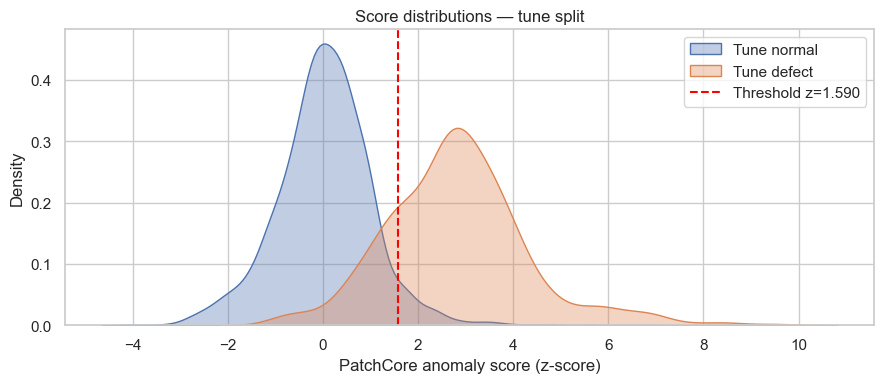

In [8]:
# ── Threshold selection  (NB1 approach: val-NORMAL only, no defect leakage) ───
# threshold = quantile(tune_normal_z, 0.95)
# Defect labels are intentionally NOT used here.
# tune_defect split is used only for diagnostic per-class breakdown below.

threshold_z = float(np.quantile(tune_normal_z, CONFIG['scoring']['threshold_quantile']))
print(f'Threshold (z-score, {CONFIG["scoring"]["threshold_quantile"]:.0%} of tune-normal): {threshold_z:.6f}')
print(f'Threshold (raw score): {threshold_z * std + mu:.6f}')

# Score distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(tune_normal_z, label='Tune normal', fill=True, alpha=0.35, ax=ax)
sns.kdeplot(tune_defect_z, label='Tune defect', fill=True, alpha=0.35, ax=ax)
ax.axvline(threshold_z, color='red', linestyle='--', label=f'Threshold z={threshold_z:.3f}')
ax.set_xlabel('PatchCore anomaly score (z-score)')
ax.set_ylabel('Density')
ax.set_title('Score distributions — tune split')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{VARIANT_NAME}_tune_score_dist.png', dpi=150)
plt.show()

ROC-AUC  : 0.9438
Avg Prec : 0.5768
Threshold z=1.5903

              precision    recall  f1-score   support

      normal       0.99      0.96      0.97     10000
     anomaly       0.47      0.80      0.59       500

    accuracy                           0.95     10500
   macro avg       0.73      0.88      0.78     10500
weighted avg       0.96      0.95      0.95     10500



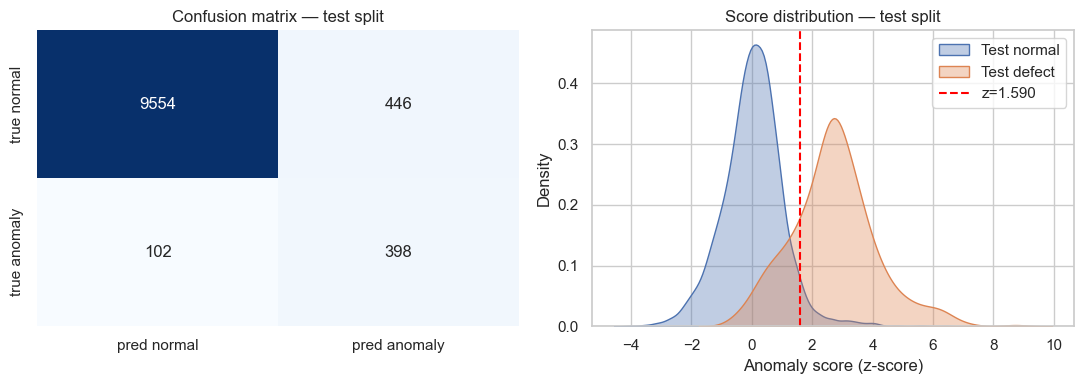


Per-defect-class recall (tune split):


,count,detected,recall,mean_score
failure_label,,,,
Scratch,22,8,0.364,1.671
Loc,74,43,0.581,1.911
Center,79,55,0.696,2.214
Edge-Loc,90,66,0.733,2.429
Edge-Ring,202,197,0.975,3.338
Donut,6,6,1.000,3.891
Near-full,3,3,1.000,6.114
Random,24,24,1.000,4.976


In [9]:
# ── Final evaluation on held-out test split ───────────────────────────────────

y_true  = np.concatenate([np.zeros(len(test_normal_z)), np.ones(len(test_defect_z))]).astype(int)
scores  = np.concatenate([test_normal_z, test_defect_z])
y_pred  = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
ap      = float(average_precision_score(y_true, scores))
report  = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])

print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'Avg Prec : {ap:.4f}')
print(f'Threshold z={threshold_z:.4f}')
print()
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'], ax=axes[0])
axes[0].set_title('Confusion matrix — test split')

sns.kdeplot(test_normal_z, label='Test normal', fill=True, alpha=0.35, ax=axes[1])
sns.kdeplot(test_defect_z, label='Test defect', fill=True, alpha=0.35, ax=axes[1])
axes[1].axvline(threshold_z, color='red', linestyle='--', label=f'z={threshold_z:.3f}')
axes[1].set_xlabel('Anomaly score (z-score)')
axes[1].set_title('Score distribution — test split')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{VARIANT_NAME}_test_eval.png', dpi=150)
plt.show()

# Per-defect-class breakdown  (diagnostic only — tune_defect used here)
tmp = tune_defect_df[['failure_label']].copy()
tmp['score']    = tune_defect_z
tmp['detected'] = (tune_defect_z > threshold_z).astype(int)
print('\nPer-defect-class recall (tune split):')
display(tmp.groupby('failure_label').agg(
    count=('detected', 'count'),
    detected=('detected', 'sum'),
    recall=('detected', 'mean'),
    mean_score=('score', 'mean'),
).round(3).sort_values('recall'))

In [10]:
# ── Secondary holdout re-evaluation  (NB1) ────────────────────────────────────
# Same fitted checkpoint + same threshold rule on a much larger distribution.
# Tests whether the model generalises beyond the original split.

cfg_h = CONFIG['holdout']
need_hn = cfg_h['test_normal_count']
need_hd = cfg_h['test_defect_count']

if len(ndf) < n3 + need_hn:
    print(f'WARNING: not enough normals for holdout ({len(ndf)} available, need {n3 + need_hn}). Skipping.')
else:
    h_rng = np.random.default_rng(SEED + 1)  # different seed → independent sample
    h_normal_df = ndf.iloc[n3: n3 + need_hn].copy()
    h_defect_df = ddf.iloc[need_d: need_d + need_hd].copy() if len(ddf) >= need_d + need_hd else ddf.iloc[need_d:].copy()

    print(f'Holdout normals: {len(h_normal_df):,} | Holdout defects: {len(h_defect_df):,}')

    Xhn, yhn = build_tensors(h_normal_df, IMAGE_SIZE)
    Xhd, yhd = build_tensors(h_defect_df, IMAGE_SIZE)

    hn_loader = DataLoader(TensorDataset(Xhn, yhn), **loader_kw)
    hd_loader = DataLoader(TensorDataset(Xhd, yhd), **loader_kw)

    hn_scores = zscore(score_loader(hn_loader, 'holdout normal'))
    hd_scores = zscore(score_loader(hd_loader, 'holdout defect'))

    # Threshold derived exactly the same way — quantile of NORMAL scores
    h_threshold = float(np.quantile(hn_scores, CONFIG['scoring']['threshold_quantile']))

    h_y_true = np.concatenate([np.zeros(len(hn_scores)), np.ones(len(hd_scores))]).astype(int)
    h_scores = np.concatenate([hn_scores, hd_scores])
    h_y_pred = (h_scores > h_threshold).astype(int)

    h_auc = float(roc_auc_score(h_y_true, h_scores))
    print(f'Holdout ROC-AUC  : {h_auc:.4f}')
    print(f'Holdout threshold: {h_threshold:.4f}')
    print(classification_report(h_y_true, h_y_pred, target_names=['normal', 'anomaly']))

    del Xhn, Xhd, hn_loader, hd_loader
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

Holdout normals: 70,000 | Holdout defects: 3,500


RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 42147840000 bytes.

PCA: 128D → 50D  (explained var: 100.0%)
UMAP fit done.


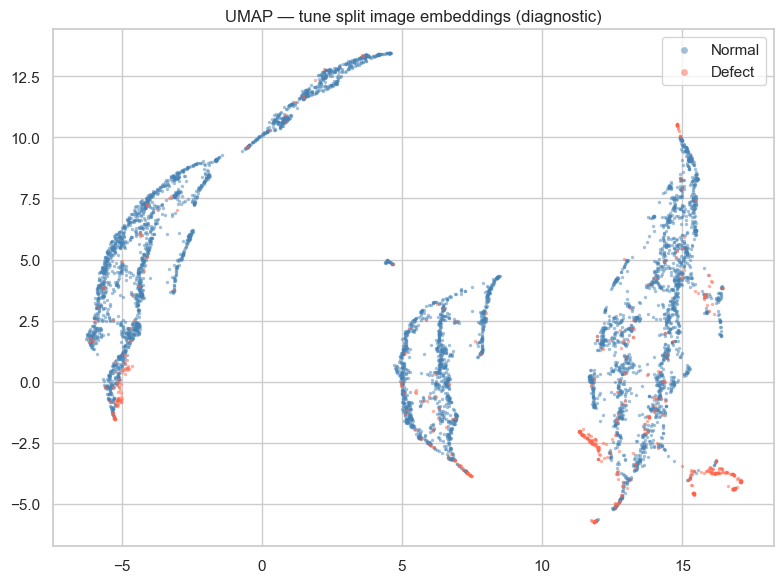

In [11]:
# ── UMAP diagnostic  (NB1 — diagnostic only, not used for threshold) ──────────
# Fit PCA → UMAP on tune-normal image embeddings, then project all splits.
# Helps visually verify that normal and defect patches separate in embedding space.

try:
    import umap.umap_ as umap
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
    raise

def collect_image_embeddings(loader: DataLoader, desc: str) -> tuple[np.ndarray, np.ndarray]:
    """Mean-pool patch embeddings to get one vector per image."""
    embs, labels = [], []
    model.eval()
    with torch.inference_mode():
        for xb, yb in tqdm(loader, desc=desc, leave=False):
            xb = xb.to(DEVICE)
            e  = model.patch_embeddings(xb).mean(dim=1).cpu().numpy()  # (B, D)
            embs.append(e)
            labels.extend(yb.tolist())
    return np.concatenate(embs), np.array(labels, dtype=np.int64)

print('Collecting embeddings for UMAP...')
tune_n_emb, tune_n_lab = collect_image_embeddings(tune_normal_loader, 'emb tune_normal')
tune_d_emb, tune_d_lab = collect_image_embeddings(tune_defect_loader, 'emb tune_defect')

all_emb = np.concatenate([tune_n_emb, tune_d_emb])
all_lab = np.concatenate([tune_n_lab, tune_d_lab])

# PCA pre-reduction (speeds up UMAP for large N)
n_pca = min(50, all_emb.shape[1], all_emb.shape[0] - 1)
pca   = PCA(n_components=n_pca, random_state=SEED)
reduced = pca.fit_transform(all_emb)
print(f'PCA: {all_emb.shape[1]}D → {n_pca}D  (explained var: {pca.explained_variance_ratio_.sum():.1%})')

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=SEED, transform_seed=SEED)
coords = reducer.fit_transform(reduced)
print('UMAP fit done.')

fig, ax = plt.subplots(figsize=(8, 6))
scatter_kw = dict(s=6, alpha=0.5, linewidths=0)
ax.scatter(coords[all_lab == 0, 0], coords[all_lab == 0, 1], c='steelblue',  label='Normal', **scatter_kw)
ax.scatter(coords[all_lab == 1, 0], coords[all_lab == 1, 1], c='tomato',     label='Defect', **scatter_kw)
ax.set_title('UMAP — tune split image embeddings (diagnostic)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{VARIANT_NAME}_umap.png', dpi=150)
plt.show()

In [ ]:
# ── Save artifacts  (NB1 structured exports) ──────────────────────────────────

summary: dict[str, Any] = {
    'variant'             : VARIANT_NAME,
    'threshold_policy'    : 'tune_normal_quantile_zscore',
    'threshold_quantile'  : CONFIG['scoring']['threshold_quantile'],
    'threshold_z'         : threshold_z,
    'train_score_mu'      : mu,
    'train_score_std'     : std,
    'roc_auc'             : roc_auc,
    'avg_precision'       : ap,
    'memory_bank_patches' : int(model.memory_bank.shape[0]),
    'patches_per_image'   : model.patches_per_image,
    'patch_embed_dim'     : model.patch_embed_dim,
    'patch_grid'          : model.patch_grid,
    'config'              : copy.deepcopy(CONFIG),
}

# JSON summary
with (OUTPUT_DIR / f'{VARIANT_NAME}_summary.json').open('w') as fh:
    json.dump(summary, fh, indent=2, default=str)

# Score CSVs
pd.DataFrame({'score_z': tune_normal_z, 'is_anomaly': 0}).to_csv(
    OUTPUT_DIR / f'{VARIANT_NAME}_tune_normal_scores.csv', index=False)
pd.DataFrame({'score_z': tune_defect_z, 'is_anomaly': 1}).to_csv(
    OUTPUT_DIR / f'{VARIANT_NAME}_tune_defect_scores.csv', index=False)
pd.DataFrame({'score_z': test_normal_z, 'is_anomaly': 0}).to_csv(
    OUTPUT_DIR / f'{VARIANT_NAME}_test_normal_scores.csv', index=False)
pd.DataFrame({'score_z': test_defect_z, 'is_anomaly': 1}).to_csv(
    OUTPUT_DIR / f'{VARIANT_NAME}_test_defect_scores.csv', index=False)

# Model checkpoint
torch.save({
    'model_state_dict' : model.state_dict(),
    'memory_bank'      : model.memory_bank.detach().cpu(),
    'summary'          : summary,
}, OUTPUT_DIR / f'{VARIANT_NAME}_checkpoint.pt')

print(f'All artifacts saved to: {OUTPUT_DIR}')
print(f'  summary JSON   : {VARIANT_NAME}_summary.json')
print(f'  score CSVs     : *_scores.csv')
print(f'  score NPZ      : {VARIANT_NAME}_scores.npz')
print(f'  checkpoint     : {VARIANT_NAME}_checkpoint.pt')
print(f'  plots          : *_tune_score_dist.png, *_test_eval.png, *_umap.png')
print(f'\nFinal ROC-AUC: {roc_auc:.4f}')

In [ ]:
# ── Memory cleanup ────────────────────────────────────────────────────────────
for _v in [
    'X_train', 'X_tune_normal', 'X_tune_defect', 'X_test_normal', 'X_test_defect',
    'train_scores', 'tune_normal_scores', 'tune_defect_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_z', 'tune_normal_z', 'tune_defect_z', 'test_normal_z', 'test_defect_z',
    'tune_n_emb', 'tune_d_emb', 'all_emb', 'reduced', 'coords',
]:
    if _v in globals():
        del globals()[_v]

gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
print('Memory cleared.')

## Notes

**Why val-normal-only threshold?**  
Using defect labels to select the threshold inflates reported metrics (label leakage). The `tune_defect` split here is used only for the per-class breakdown diagnostic — never to choose the threshold.

**Why z-score normalisation?**  
Raw PatchCore distances depend on the scale of the embedding space. Z-scoring against train-normal `(mu, std)` makes thresholds interpretable ("z=1.5 means 1.5 standard deviations above the normal mean") and comparable across model variants.

**Why seeded CPU `torch.Generator`?**  
GPU `torch.randperm` without an explicit generator produces different results across runs and machines. The seeded CPU generator guarantees the exact same patch subset is sampled into the memory bank every run.

**Why `patch_embed_dim=128` instead of 512?**  
Wafer maps are 3-channel binary images (background / edge / die). EfficientNet block 3 produces a moderate-depth feature map; projecting it to 512 dimensions with a random (never-trained) linear layer spreads the mass too thin. 128 keeps the cosine-similarity distances well-conditioned.

**Tuning tips:**
- Increase `memory_bank_max_patches` if VRAM allows — more patches → better coverage → better recall on rare defects.
- Adjust `threshold_quantile` (95th → 99th) to trade recall for precision.
- Try `effnet_feature_idx=4` for deeper features at the cost of a smaller spatial patch grid.
- The UMAP cell is slow on large splits — reduce loader sizes or skip if not needed.